# Envirnoment

In [1]:
import argopy
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Fetching GEONET DATA


In [ ]:
# Function for creating data table from the GeoNet API

def API_Data(
    station: str,# NZ(A-L)
    name: str, # water-height(-detided) water-temperature water-pressure
    method: str, # 15s 15m raw


    sensor_code: str = "-", # 40 41 42 | periods between maintaince for DART
    aspect: str = "-", # - autofills for what is avaliable


    domain: str = "dart", # GeoNet Network
    startdate: str = "2019-01-01", #yyyy-mm-dd UTC
    enddate: str = "2025-09-01",
    aggregation_period: str = "", #1m 5m 10m 15m 30m 1h 2h 3h 4h 6h 8h 12h 1d
    aggregation_function: str = "" #min max mean sum perc(N)
    ):

    url = f"https://tilde.geonet.org.nz/v4/data/dart/{station}/{name}/{sensor_code}/{method}/{aspect}/{startdate}/{enddate}?aggregationPeriod={aggregation_period}&aggregationFunction={aggregation_function}"

    json_data = requests.get(url).json()
    
    # Request Json Data into Panda format
    panda_data = pd.json_normalize(json_data,
                                   record_path='data',
                                   meta= [['series', 'sensorCode'],['series', 'method'],['series', 'name']],
                                   sep=',')
    panda_data['ts'] = pd.to_datetime(panda_data["ts"])
    panda_data['series,sensorCode'] = panda_data['series,sensorCode'].astype(int)
    panda_data

    return panda_data

In [11]:
WH_15s = API_Data(
    station="NZE",
    name="water-height",
    method="15s",
    sensor_code="40",
)

In [12]:
WH_15m = API_Data(
    station="NZE",
    name="water-height",
    method="15m",
    sensor_code="40",
    )

In [13]:
WT_raw = API_Data(
    station="NZE",
    name="water-temperature",
    method="raw",
    sensor_code="40",
)

In [14]:
WP_raw = API_Data(
    station="NZE",
    name="water-pressure",
    method="raw",
    sensor_code="40",
)

# DART NETWORK


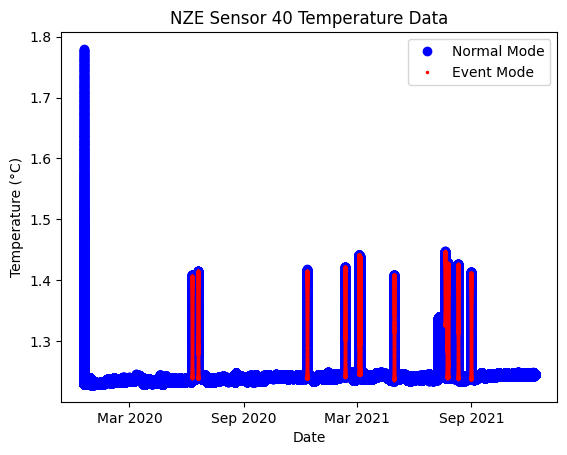

In [15]:

filtered_15s = WT_raw[WT_raw['ts'].isin(WH_15s['ts'])]
fig, ax = plt.subplots()

# Plotting
ax.plot(WT_raw['ts'],WT_raw['val'],'b.', markersize=12 , label='Normal Mode')
ax.plot(filtered_15s['ts'],filtered_15s['val'], 'r.', markersize=3,label='Event Mode')

# Formating y label
ax.set_ylabel("Temperature (°C)")

# Formating x label
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6)) # X axis display every 6 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))


ax.set_title("NZE Sensor 40 Temperature Data")
ax.legend()


In [16]:
# Identifying period of event mode

gap = "15s" # time differences to determine different periods
before = "13D" # n days visable before / after
after = "1D"

period_filters = (WH_15s["ts"].diff() > pd.Timedelta(gap)).cumsum()
event_periods = WH_15s.groupby([period_filters, WH_15s['series,sensorCode']])['ts'].agg(["first", "last"])

event_periods['duration'] = event_periods['last'] - event_periods['first']
event_periods['before'] = event_periods['first'] - pd.Timedelta(before)
event_periods['after'] = event_periods['last'] + pd.Timedelta(after)
event_periods


,,first,last,duration,before,after
ts,"series,sensorCode",,,,,
0,40,2020-06-10 01:00:00+00:00,2020-06-10 03:25:00+00:00,0 days 02:25:00,2020-05-28 01:00:00+00:00,2020-06-11 03:25:00+00:00
1,40,2020-06-18 12:00:00+00:00,2020-06-18 16:59:45+00:00,0 days 04:59:45,2020-06-05 12:00:00+00:00,2020-06-19 16:59:45+00:00
2,40,2020-12-10 21:00:00+00:00,2020-12-10 23:25:30+00:00,0 days 02:25:30,2020-11-27 21:00:00+00:00,2020-12-11 23:25:30+00:00
3,40,2021-02-10 13:00:00+00:00,2021-02-10 16:59:45+00:00,0 days 03:59:45,2021-01-28 13:00:00+00:00,2021-02-11 16:59:45+00:00
4,40,2021-03-04 13:00:00+00:00,2021-03-04 20:59:45+00:00,0 days 07:59:45,2021-02-19 13:00:00+00:00,2021-03-05 20:59:45+00:00
5,40,2021-03-04 21:08:30+00:00,2021-03-05 04:59:45+00:00,0 days 07:51:15,2021-02-19 21:08:30+00:00,2021-03-06 04:59:45+00:00
6,40,2021-03-05 08:00:00+00:00,2021-03-05 11:59:45+00:00,0 days 03:59:45,2021-02-20 08:00:00+00:00,2021-03-06 11:59:45+00:00
7,40,2021-03-06 00:00:00+00:00,2021-03-06 03:59:45+00:00,0 days 03:59:45,2021-02-21 00:00:00+00:00,2021-03-07 03:59:45+00:00
8,40,2021-03-06 11:00:00+00:00,2021-03-06 15:54:45+00:00,0 days 04:54:45,2021-02-21 11:00:00+00:00,2021-03-07 15:54:45+00:00


Text(0.5, 0, 'Date')

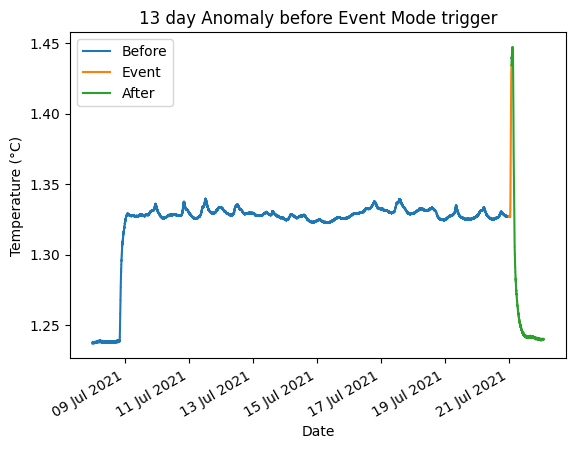

In [17]:
# Achieved function used to view data b4, during, and after event mode

n_event = 11 # the n period event mode was active
data_type = WT_raw #WH_15s, WH_15m, WP_raw, WT_raw

# Get the sensor code for the specified period index

fig, ax = plt.subplots()

filtered_before = data_type[data_type['ts'].between(event_periods['before'].iloc[n_event], event_periods['first'].iloc[n_event])]
filtered_event = data_type[data_type['ts'].between(event_periods['first'].iloc[n_event], event_periods['last'].iloc[n_event])]
filtered_after = data_type[data_type['ts'].between(event_periods['last'].iloc[n_event], event_periods['after'].iloc[n_event])]


plt.plot(filtered_before['ts'],filtered_before['val'], label='Before')
plt.plot(filtered_event['ts'],filtered_event['val'], label='Event')
plt.plot(filtered_after['ts'],filtered_after['val'], label='After')

plt.legend()
plt.gcf().autofmt_xdate()


ax.set_title("13 day Anomaly before Event Mode trigger")
ax.set_ylabel("Temperature (°C)")


ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y')) # format
ax.set_xlabel("Date")

Text(0.5, 1.0, 'Preasure and Temperature during Event Mode')

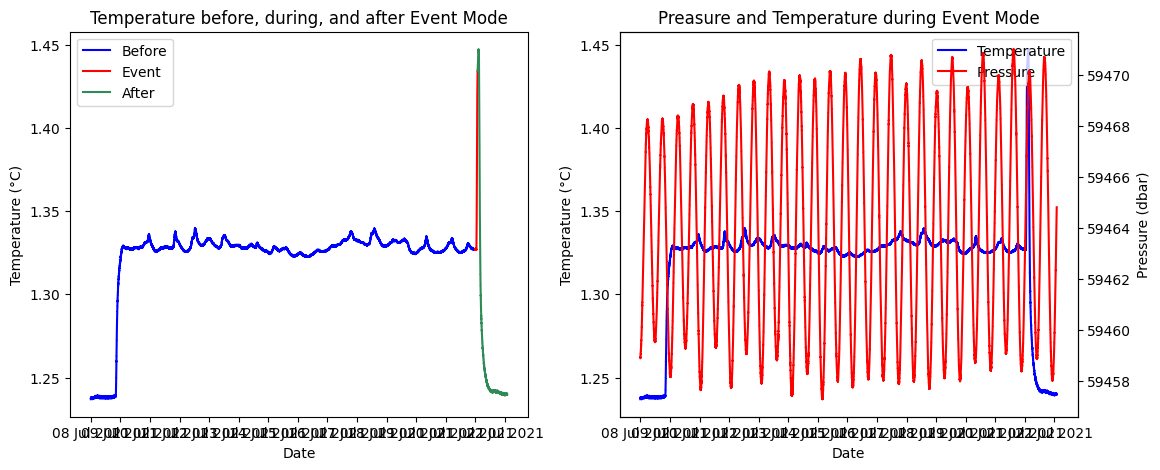

In [20]:
# comparing temperature and pressure during periods around an event mode

x= 11

# ax1 filtered data
filtered_before = data_type[data_type['ts'].between(event_periods['before'].iloc[x], event_periods['first'].iloc[x])]
filtered_event = data_type[data_type['ts'].between(event_periods['first'].iloc[x], event_periods['last'].iloc[x])]
filtered_after = data_type[data_type['ts'].between(event_periods['last'].iloc[x], event_periods['after'].iloc[x])]

# ax2 filtered data
filtered_temperture = WT_raw[WT_raw['ts'].between(event_periods['before'].iloc[x], event_periods['after'].iloc[x])]
filtered_pressure = WP_raw[WP_raw['ts'].between(event_periods['before'].iloc[x], event_periods['after'].iloc[x])]




# Creating Plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13, 5))



### Plotting ax1
ax1.plot(filtered_before['ts'],filtered_before['val'], 'b-', label='Before')
ax1.plot(filtered_event['ts'],filtered_event['val'],'r-', label='Event')
ax1.plot(filtered_after['ts'],filtered_after['val'], 'seagreen', label='After')

# Fpr,atomg y axis
ax1.set_ylabel("Temperature (°C)")

# Formating x axis
ax1.xaxis.set_major_locator(mdates.DayLocator()) # Xaxis display every 24hrs
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y')) # format
ax1.set_xlabel("Date")

ax1.legend()
ax1.set_title("Temperature before, during, and after Event Mode")




### Plotting ax2
ax2x = ax2.twinx()
ax2.plot(filtered_temperture['ts'],filtered_temperture['val'], "b", label="Temperature")
ax2x.plot(filtered_pressure['ts'],filtered_pressure['val'], "r", label="Pressure")

# Formating y label
ax2.set_ylabel("Temperature (°C)")
ax2x.set_ylabel("Pressure (dbar)")

# Formating x axis
ax2.xaxis.set_major_locator(mdates.DayLocator()) # Xaxis display every 24hrs
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y')) # format
ax2.set_xlabel("Date")

# Grabbing the labels from each axis
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2x.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Formating title
plt.title("Preasure and Temperature during Event Mode")

Text(0.5, 1.0, 'First 7 days of Data Collection')

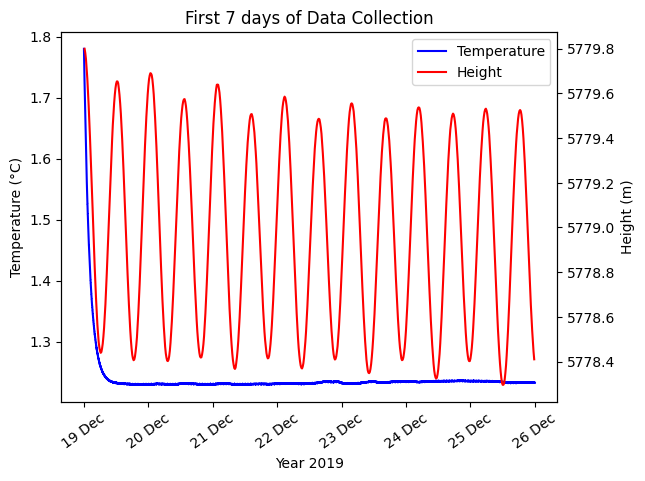

In [ ]:
# looking at the temperature spike at the start of the data

before_date = "2019-12-26 0:00:00"

e = WT_raw[WT_raw['ts'] < before_date] #14th hr is when it reaches WT_raw["val"].mean()
ee = WH_15m[WH_15m['ts'] < before_date]
eee = WP_raw[WP_raw['ts'] < before_date]

# Creating plot
fig, ax1 = plt.subplots()
ax2 = ax1.twinx() # create an additional y axis
ax1.plot(e['ts'],e['val'], "-", label="Temperature", c='b')
ax2.plot(ee['ts'],ee['val'], "-", label="Height", c="r" )

# Formating y axis
ax1.set_ylabel("Temperature (°C)")
ax2.set_ylabel("Height (m)")

# Formating x axis
ax1.xaxis.set_major_locator(mdates.DayLocator()) # Xaxis display every 24hrs
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) # format
ax1.tick_params(axis='x', rotation=36)
ax1.set_xlabel("Year 2019")

# Grabbing the labels from each axis
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

# Formating title
plt.title("First 7 days of Data Collection")

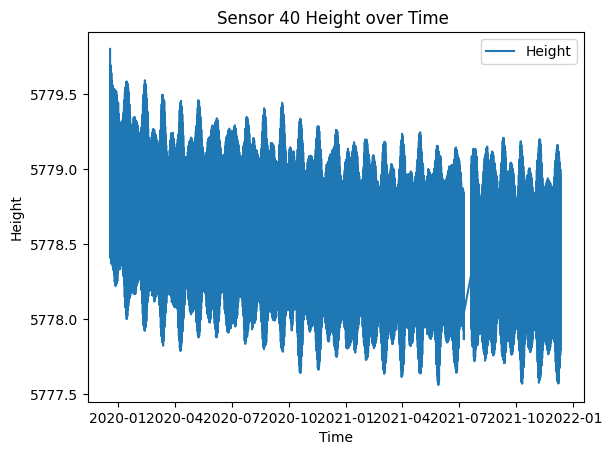

In [19]:
# change in height over time

plt.plot(WH_15m['ts'],WH_15m['val'], label="Height")

plt.title("Sensor 40 Height over Time ")
plt.ylabel("Height")
plt.xlabel("Time")
plt.legend()

Text(0, 0.5, 'Pressure (dbar)')

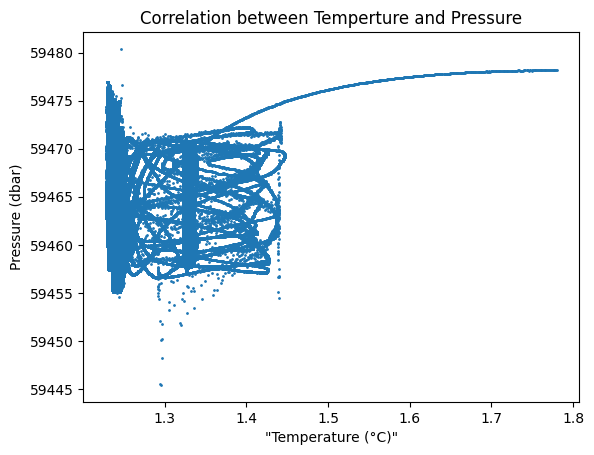

In [21]:
# scatter plot of temperature and pressure

plt.scatter(WT_raw['val'],WP_raw['val'], s=1)

plt.title('Correlation between Temperture and Pressure')
plt.xlabel('"Temperature (°C)"')
plt.ylabel('Pressure (dbar)')

Text(0, 0.5, 'Pressure')

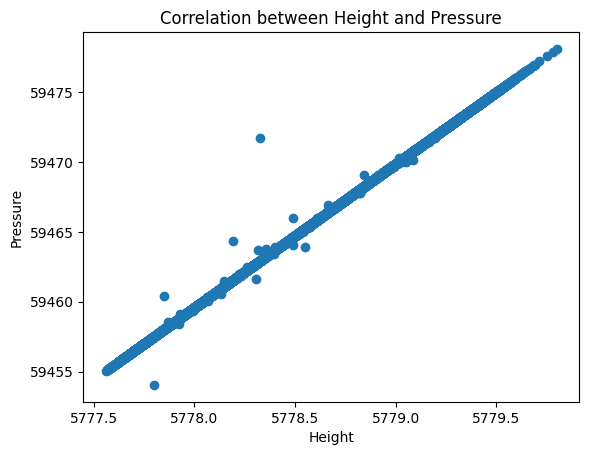

In [22]:
plt.scatter( WH_15m['val'], WP_raw[ WP_raw['ts'].isin(WH_15m['ts']) ]['val'])

plt.title('Correlation between Height and Pressure')
plt.xlabel('Height')
plt.ylabel('Pressure')

# ARGO


In [23]:
# Using argopy to get data near ZNE station

ArgoData = argopy.DataFetcher().region([-180, -175, -39, -33, 5750, 5800,'2020-01','2022-01'])
ArgoData = ArgoData.to_dataframe()
ArgoData = ArgoData[(ArgoData['PLATFORM_NUMBER'] != 5906418) | (ArgoData['CYCLE_NUMBER'] != 29)] # cleaning the argodata
# ArgoData.plot("TIME","TEMP",kind="scatter")

In [ ]:
ArgoData['PLATFORM_NUMBER'].unique()


array([5905163, 5902447, 5906420, 5906416, 5906419, 5906418])

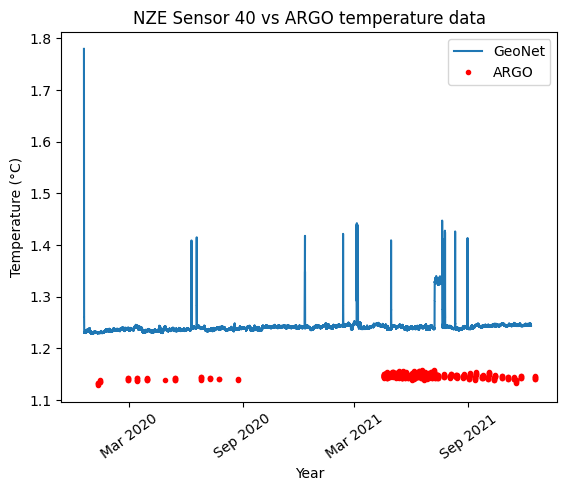

In [ ]:
# comparing dart and argo temperature

fig, ax = plt.subplots()

# Plotting
ax.plot(WT_raw['ts'], WT_raw['val'], label='GeoNet')
ax.plot(ArgoData['TIME'], ArgoData['TEMP'],"r.", label='ARGO')

# Formating y label
ax.set_ylabel("Temperature (°C)")

# Formating x label
ax.set_xlabel("Year")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6)) # X axis display every 6 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=36)


ax.set_title("NZE Sensor 40 vs ARGO temperature data")
ax.legend()

Text(2019-12-20 00:00:15+00:00, 1.25271, 'Max: 1.253 \nMin: 1.228')

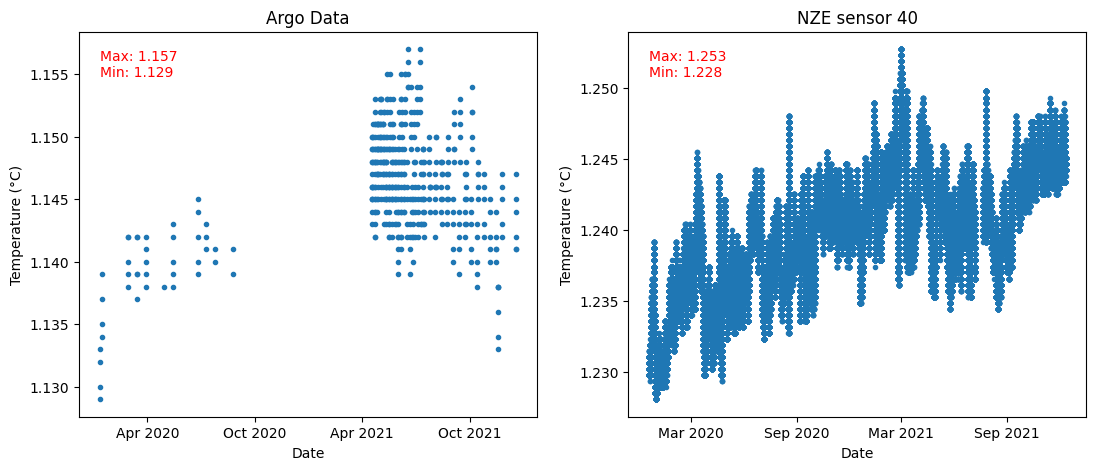

In [ ]:
# compare the data range of dart and argo

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(13, 5))

ax1.plot(ArgoData['TIME'],ArgoData['TEMP'],'.')

e = WT_raw['ts'][ WT_raw['val'] > 1.26].dt.date
ee = WT_raw[~WT_raw['ts'].dt.date.isin(e)]

#ee = WT_raw[(WT_raw['ts'].dt.year == 2021) & (WT_raw['ts'].dt.month == 3)]
ax2.plot(ee['ts'],ee['val'],'.')



ax1.set_title("Argo Data")
ax1.set_xlabel("Date")
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.set_ylabel("Temperature (°C)")

ax2.set_title("NZE sensor 40")
ax2.set_xlabel("Date")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.set_ylabel("Temperature (°C)")

ax1_min, ax1_max = ArgoData['TEMP'].min(), ArgoData['TEMP'].max()
ax1.text(ArgoData['TIME'].iloc[1], ArgoData['TEMP'].max(), f"Max: {ax1_max:.3f} \nMin: {ax1_min:.3f}", color='red', va='top')

ax2_min, ax2_max = ee['val'].min(), ee['val'].max()
ax2.text(ee['ts'].iloc[1], ee['val'].max(), f"Max: {ax2_max:.3f} \nMin: {ax2_min:.3f}", color='red', va='top')


# Fetching Aggregated Data


In [27]:
# Storing all station temperaance, height, and pressure data into a dictionary
# data is aggregated to load faster as we are comparing between stations

Station_list = ["NZA", "NZB", "NZC", "NZD", "NZE", "NZF", "NZG", "NZH","NZI", "NZJ", "NZK","NZL"]
SensorCode_list = ["40" ,"41", "42"]

In [28]:
AggT = {}

for station in Station_list:
    AggT[station] = {}
    for sensor_code in SensorCode_list:
        try:
            AggT[station][sensor_code] = API_Data(
                station=station,
                name="water-temperature",
                method="raw",
                sensor_code=sensor_code,
                aggregation_period="1d",
                aggregation_function="mean"
            )
        except Exception as e:
            continue


In [29]:
Agg15m = {}

for station in Station_list:
    Agg15m[station] = {}
    for sensor_code in SensorCode_list:
        try:
            Agg15m[station][sensor_code] = API_Data(
                station=station,
                name="water-height",
                method="15m",
                sensor_code=sensor_code,
                aggregation_period="1d",
                aggregation_function="mean"
            )
        except Exception as e:
            continue


In [30]:
AggP = {}

for station in Station_list:
    AggP[station] = {}
    for sensor_code in SensorCode_list:
        try:
            AggP[station][sensor_code] = API_Data(
                station=station,
                name="water-pressure",
                method="raw",
                sensor_code=sensor_code,
                aggregation_period="1d",
                aggregation_function="mean"
            )
        except Exception as e:
            continue


In [31]:
Agg15s = {}

for station in Station_list:
    Agg15s[station] = {}
    for sensor_code in SensorCode_list:
        try:
            Agg15s[station][sensor_code] = API_Data(
                station=station,
                name="water-height",
                method="15s",
                sensor_code=sensor_code,
                aggregation_period="1d",
                aggregation_function="mean"
            )
        except Exception as e:
            continue


# Station Comparison

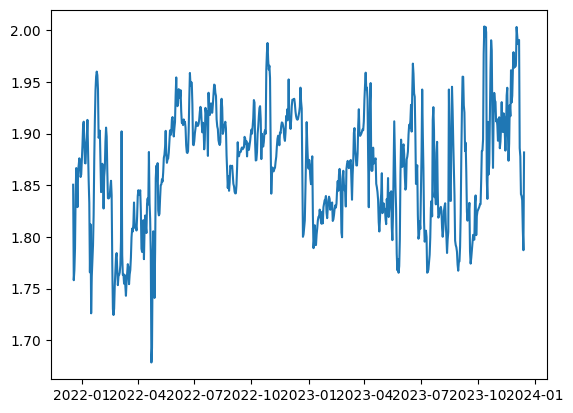

In [33]:
# code to graph the data for one sensor

Agg = AggT
station = "NZA"
sensor_code = "41"

plt.plot(Agg[station][sensor_code]['ts'],Agg[station][sensor_code]['val'])

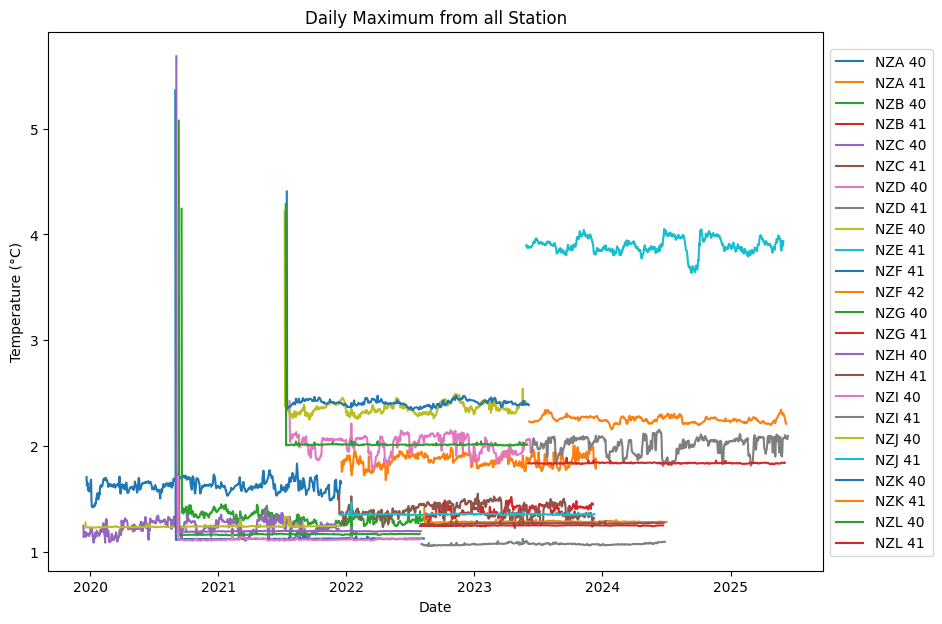

In [34]:
# graphing all sensor's temperature data agaisnt each other

fig, ax = plt.subplots(figsize=(10, 7))

for station in AggT:
  for sensor_code in AggT[station]:
    ax.plot(AggT[station][sensor_code]['ts'],AggT[station][sensor_code]['val'], label= f'{station} {sensor_code}')


ax.set_title("Daily Maximum from all Station")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(loc = 'upper left', bbox_to_anchor=(1, .98))

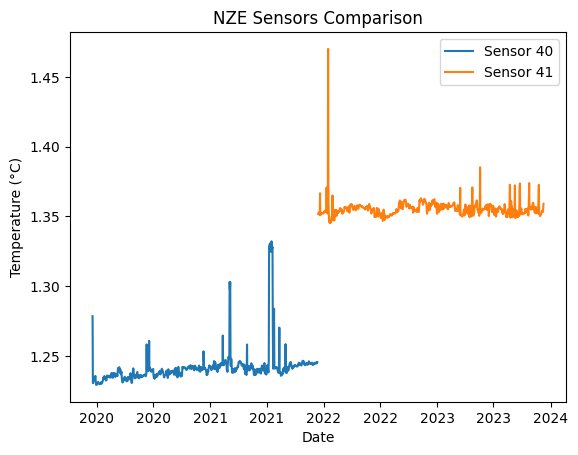

In [35]:
# comparing temperature data of statin NZE sensors

fig, ax = plt.subplots()

for sensor_code in AggT["NZE"]:
  ax.plot(AggT["NZE"][sensor_code]['ts'],AggT["NZE"][sensor_code]['val'], label = f'Sensor {sensor_code}')

ax.set_title("NZE Sensors Comparison")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylabel("Temperature (°C)")
ax.legend()

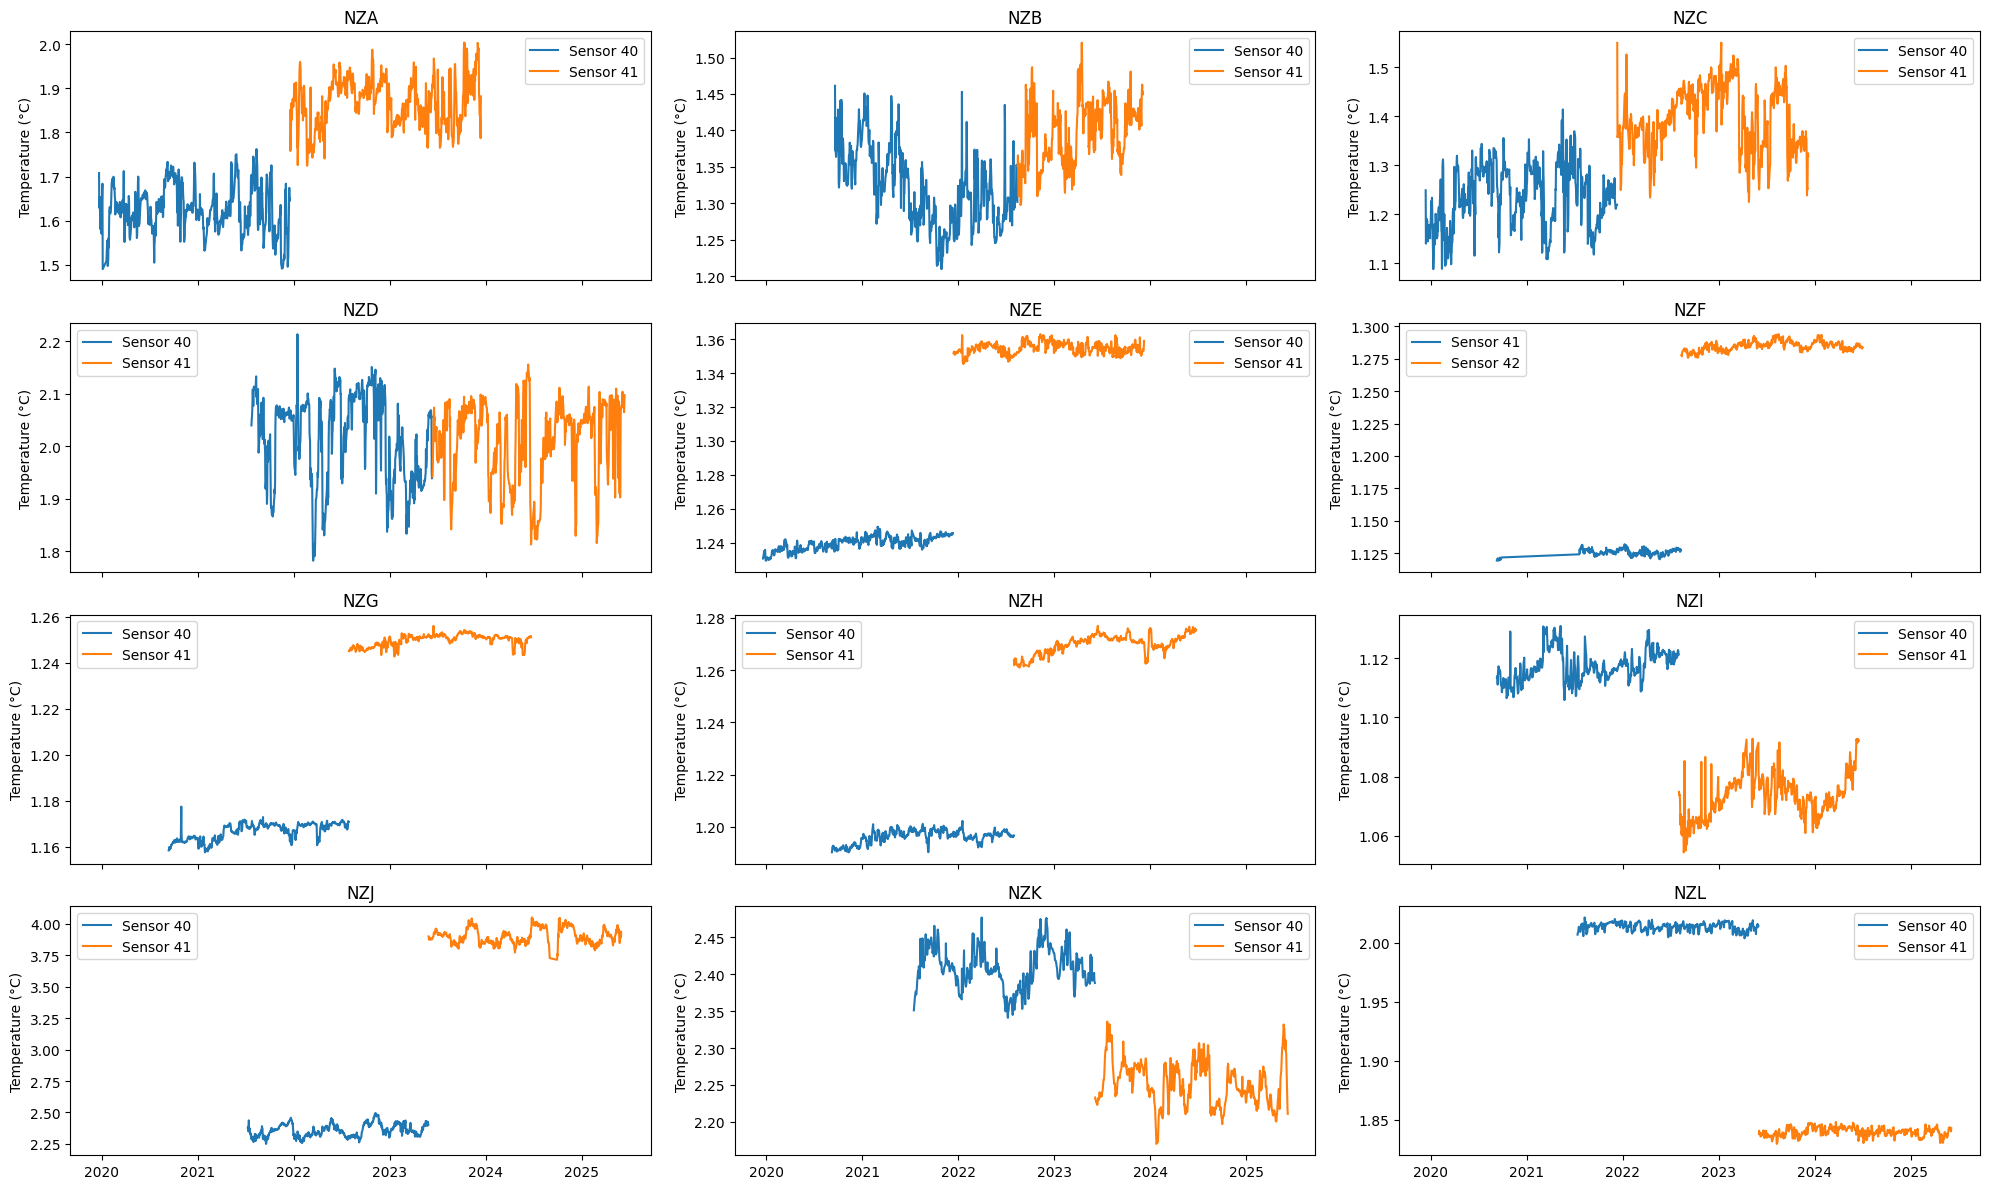

In [36]:
# comparing station's sensor against each other at every station

fig, ax = plt.subplots(4, 3, figsize=(20, 12),sharex=True)
ax = ax.flatten()  # flatten to 1D array for easy indexing
i = 0

for station in AggT:
  for sensor_code in AggT[station]:
    # Get data for the current station and sensor code
    df = AggT[station][sensor_code].copy()

    # Outlier removal using IQR
    Q1 = df['val'].quantile(0.25)
    Q3 = df['val'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df['val'] > lower_bound) & (df['val'] < upper_bound)].copy()

    # Plot the data
    ax[i].plot(df['ts'],df['val'], label= f'Sensor {sensor_code}')

  ax[i].legend(loc = 'best')
  ax[i].set_title(station)
  ax[i].set_ylabel("Temperature (°C)")
  i += 1

plt.tight_layout() # Adjust layout to prevent labels overlapping

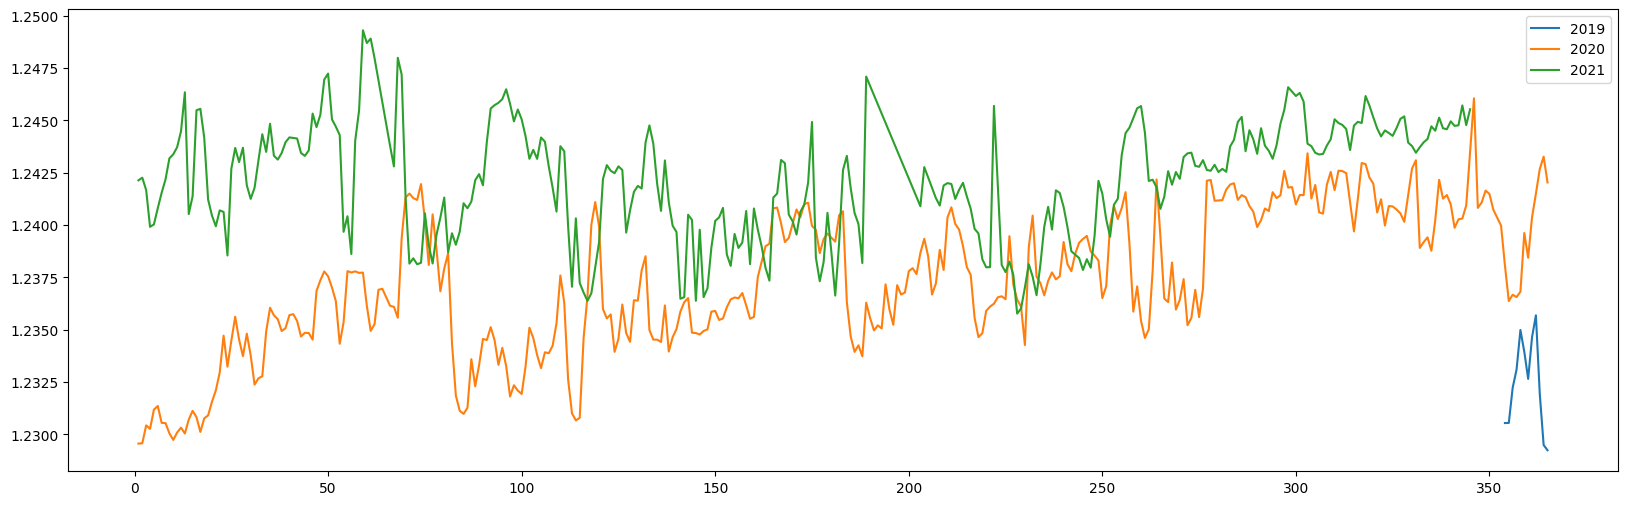

In [37]:
# comparing station NZE sensor 40 yearly data 

e = AggT['NZE']['40']
e = e[e['val'] < 1.25]
#e = e[ e['val'].median()         ]

fig, ax = plt.subplots(figsize = (20,6))

for year in pd.to_datetime(e['ts'].dt.year.unique(), format='%Y', utc=True): #find all unique year in table and transform them into
  ee = e[(e['ts'] >= year) & (e['ts'] < (year + pd.Timedelta(days=365)))]
  plt.plot(ee['ts'].dt.dayofyear, ee['val'],label = year.strftime('%Y'))

plt.legend()

(np.float64(18262.0), np.float64(18262.997916666667))

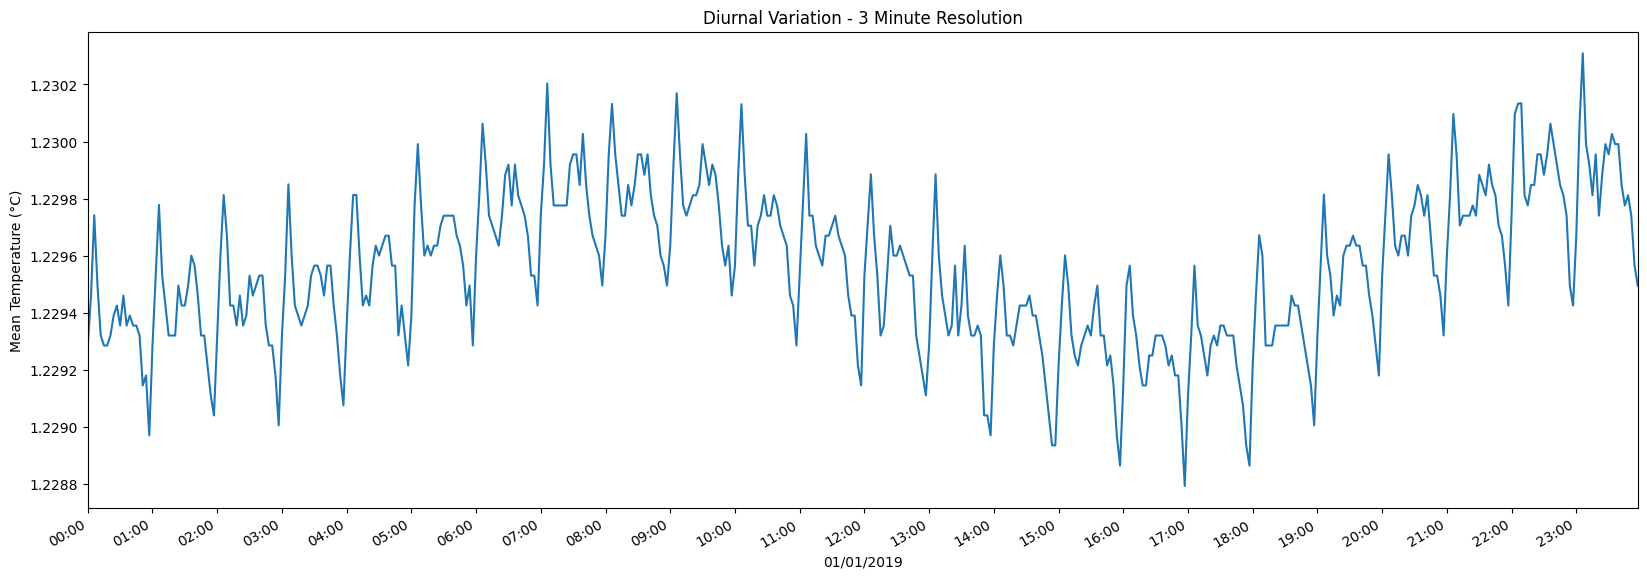

In [41]:
# NZE 40, 1/1/2020 diurnal graph

fig, ax = plt.subplots(figsize=[20,7])


e = WT_raw[(WT_raw['ts'].dt.year == 2020) & (WT_raw['ts'].dt.month == 1) & (WT_raw['ts'].dt.day==1)].copy()
e_resampled = e.set_index('ts').resample('3min')['val'].mean().reset_index() #aggerating the data into 3 min intervals


ax.plot(e_resampled['ts'],e_resampled['val'])

ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate()

ax.set_xlabel("01/01/2019")
ax.set_ylabel("Mean Temperature (°C)")
ax.set_title("Diurnal Variation - 3 Minute Resolution")
plt.xlim(e_resampled['ts'].iloc[0], e_resampled['ts'].iloc[-1])

(np.float64(18262.0), np.float64(18292.958333333332))

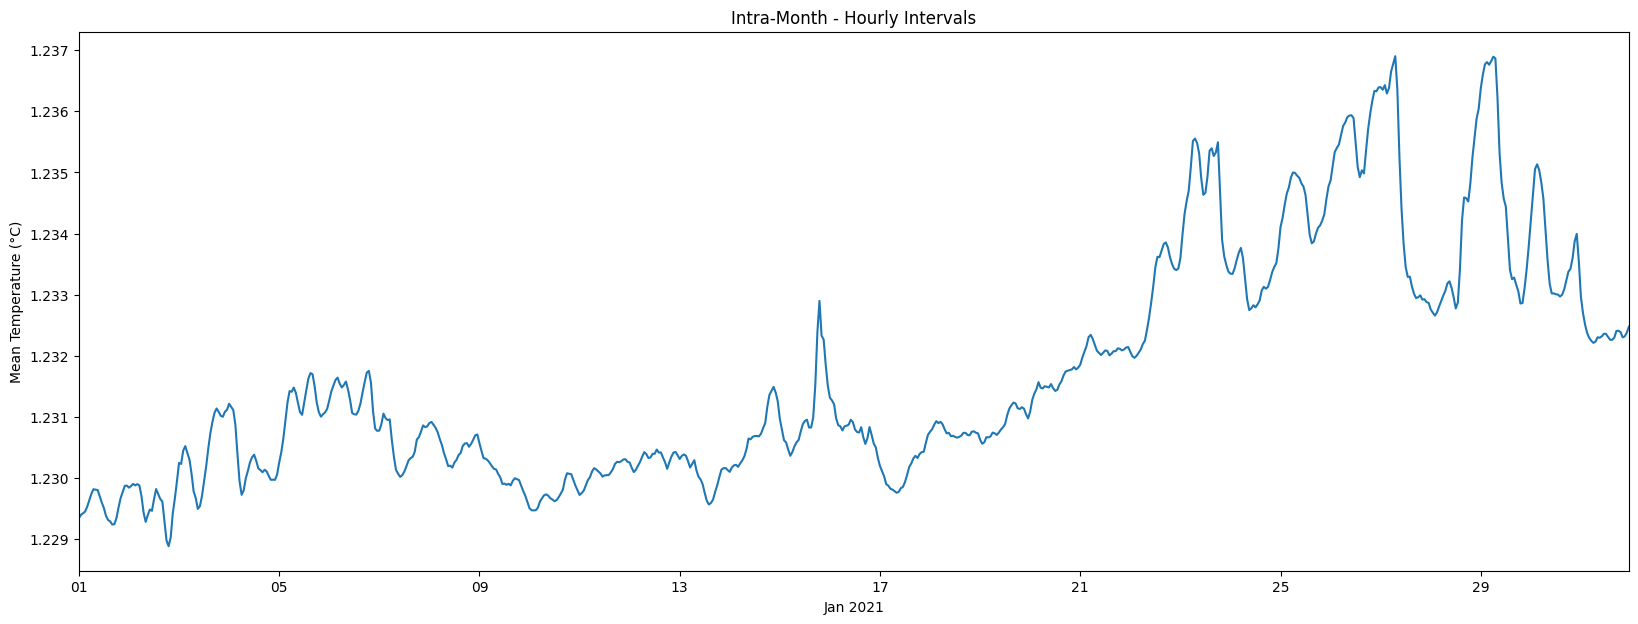

In [46]:
# NZE 40, Jan 2020 monthly graph

fig, ax = plt.subplots(figsize=[20,7])

e = WT_raw[(WT_raw['ts'].dt.year == 2020) & (WT_raw['ts'].dt.month == 1 )].copy() # selecting 2020 jan
e_resampled = e.set_index('ts').resample('1h')['val'].mean().reset_index() # 1 hour intervals means


ax.plot(e_resampled['ts'],e_resampled['val'])


ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))


ax.set_xlabel("Jan 2021")
ax.set_ylabel("Mean Temperature (°C)")
ax.set_title("Intra-Month - Hourly Intervals")
plt.xlim(e_resampled['ts'].iloc[0], e_resampled['ts'].iloc[-1])

(np.float64(18262.0), np.float64(18627.875))

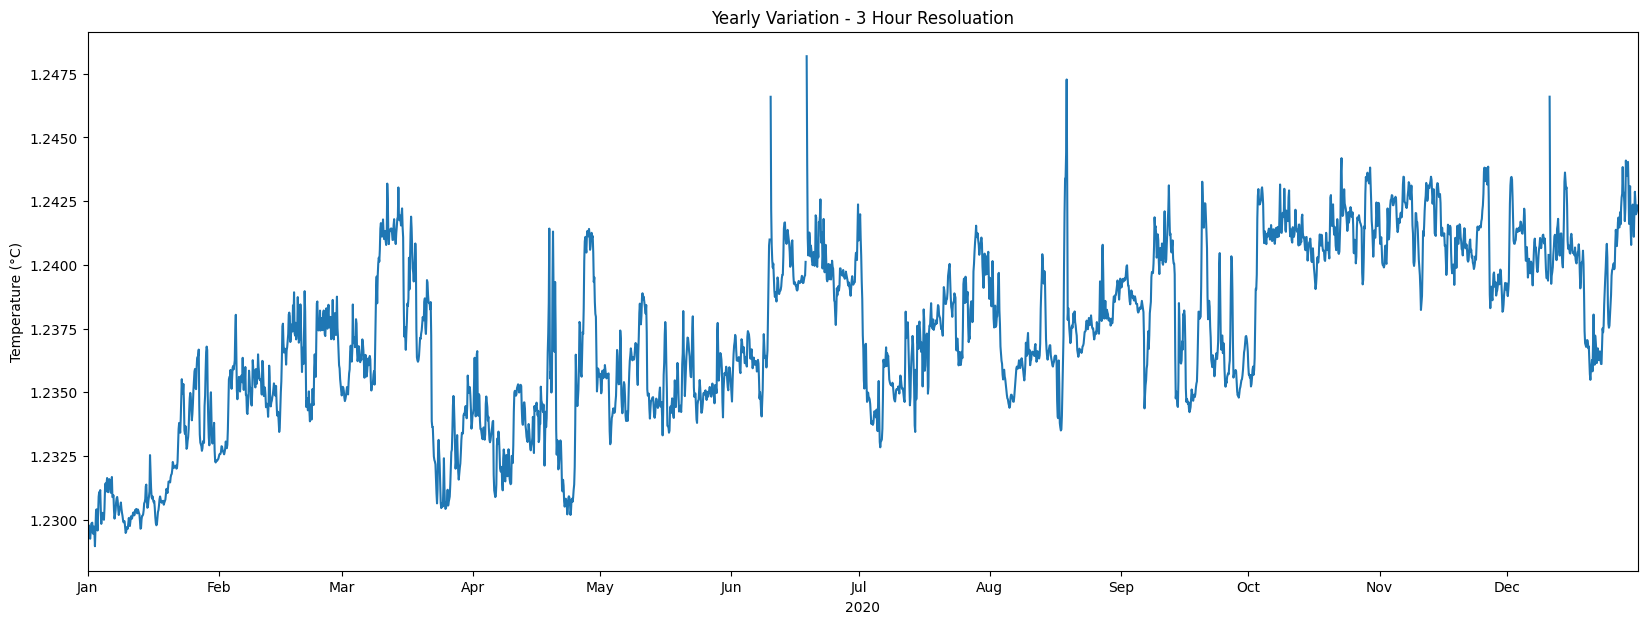

In [47]:
# NZE 40, 2020 year graph

fig, ax = plt.subplots(figsize=[20,7])


e = WT_raw[(WT_raw['ts'].dt.year == 2020)].copy()
e = e[e['val'] < 1.25]
e_resampled = e.set_index('ts').resample('3h')['val'].mean().reset_index()


ax.plot(e_resampled['ts'],e_resampled['val'])



# Format x-axis to show hours and minutes
#ax.xaxis.set_major_locator(mdates.HourLocator(interval=1)) # Set major ticks every hour
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) # Format as hour:minute


ax.set_xlabel("2020")
ax.set_ylabel("Temperature (°C)") # Updated y-axis label
ax.set_title("Yearly Variation - 3 Hour Resoluation") # Updated title
plt.xlim(e_resampled['ts'].iloc[0], e_resampled['ts'].iloc[-1])